In [8]:
# Cell 1: Setup and Imports
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style for better looking plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style="whitegrid")

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [15]:
# Cell 2: Load the enriched model
# Directly load the enriched model (we know it's better)
from src.preprocessing.baf_preprocessor import BAFPreprocessor, TimeSplit

path = Path('/Users/juliahandiprima/Downloads/Fraud-Detection')

# Load model
model_path = path / "results/enriched/model.pkl"
print("Loading model...")
model = joblib.load(model_path)
print(f"✅ Model loaded")

# Create new preprocessor
print("\nCreating new preprocessor...")
preprocessor = BAFPreprocessor()
split = TimeSplit()

# Load and prepare data
df = pd.read_csv(path / "data" / "Base.csv")
train_df, valid_df, test_df = preprocessor.split_by_month(df, split)
preprocessor.fit(train_df)

print(f"✅ Preprocessor created and fitted")
print(f"   Test samples: {len(test_df)}")

Loading model...
✅ Model loaded

Creating new preprocessor...
✅ Preprocessor created and fitted
   Test samples: 96843


In [16]:
# Cell 3: Load and prepare test data
from src.preprocessing.baf_preprocessor import TimeSplit

# Transform test data
X_test, y_test = preprocessor.transform_with_target(test_df)

print(f"Test data shape: {X_test.shape}")
print(f"Feature names: {list(X_test.columns[:5])}...")
print(f"Fraud cases in test set: {(y_test == 1).sum()}")
print(f"Legitimate cases: {(y_test == 0).sum()}")

Test data shape: (96843, 52)
Feature names: ['income', 'name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'customer_age']...
Fraud cases in test set: 1428
Legitimate cases: 95415


In [17]:
# Cell 4: Add retriever features for enriched model
from src.retriever.enrichment import build_retriever_features_for_records

print("Adding retriever features...")
retr_test = build_retriever_features_for_records(test_df.drop(columns=['fraud_bool']))
X_test = pd.concat([X_test, retr_test], axis=1)

print(f"Final test data shape: {X_test.shape}")
print(f"Features include retriever columns: {[c for c in X_test.columns if c.startswith('retr_')]}")

Adding retriever features...
Final test data shape: (96843, 57)
Features include retriever columns: ['retr_local_fraud_rate', 'retr_total_neighbors', 'retr_fraud_neighbors', 'retr_similarity_mean', 'retr_similarity_max']


In [18]:
# Cell 5: Calculate SHAP values (this may take a few minutes)
import shap

# Use subset for faster computation
n_samples = min(500, len(X_test))
X_sample = X_test.iloc[:n_samples]
y_sample = y_test.iloc[:n_samples]

print(f"\nCalculating SHAP values for {n_samples} samples...")
print("This may take 1-3 minutes...")

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

print("✅ SHAP values calculated!")


Calculating SHAP values for 500 samples...
This may take 1-3 minutes...
✅ SHAP values calculated!


In [19]:
# Cell 6: Feature importance (mean absolute SHAP)
mean_abs_shap = np.abs(shap_values).mean(axis=0)
feature_importance = pd.DataFrame({
    'feature': X_sample.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

print("\n" + "="*70)
print("TOP 20 MOST INFLUENTIAL FEATURES")
print("="*70)
for i, row in feature_importance.head(20).iterrows():
    print(f"{row['feature']:50s}: {row['mean_abs_shap']:.4f}")

# Display as DataFrame for better viewing
feature_importance.head(20)


TOP 20 MOST INFLUENTIAL FEATURES
customer_age                                      : 0.8999
income                                            : 0.6830
housing_status_BA                                 : 0.6566
device_os_windows                                 : 0.5214
phone_home_valid                                  : 0.4681
current_address_months_count                      : 0.3866
proposed_credit_limit                             : 0.3836
email_is_free                                     : 0.3075
keep_alive_session                                : 0.3007
date_of_birth_distinct_emails_4w                  : 0.2784
has_other_cards                                   : 0.2712
name_email_similarity                             : 0.2351
bank_months_count                                 : 0.2197
zip_count_4w                                      : 0.1862
prev_address_months_count                         : 0.1772
employment_status_CA                              : 0.1601
month                 

,feature,mean_abs_shap
4,customer_age,0.899853
0,income,0.683000
38,housing_status_BA,0.656602
50,device_os_windows,0.521383
15,phone_home_valid,0.468053
3,current_address_months_count,0.386562
19,proposed_credit_limit,0.383599
14,email_is_free,0.307460
22,keep_alive_session,0.300690
12,date_of_birth_distinct_emails_4w,0.278419


In [20]:
# Cell 7: Save feature importance to CSV
feature_importance.to_csv("shap_feature_importance_enriched.csv", index=False)
print("✅ Saved: shap_feature_importance_enriched.csv")

✅ Saved: shap_feature_importance_enriched.csv


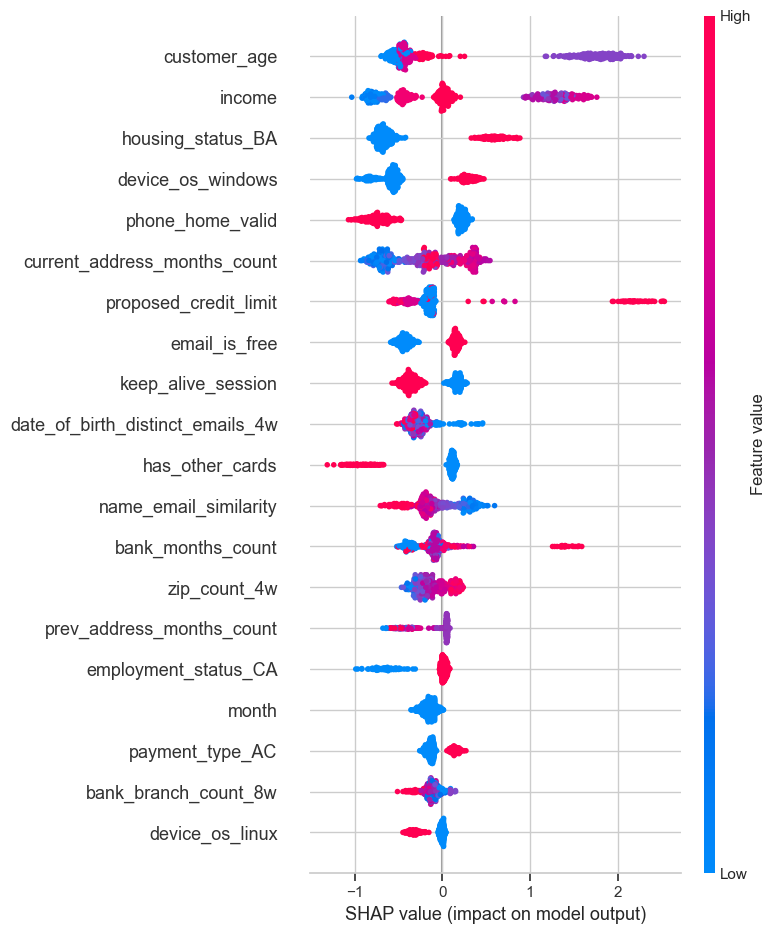

In [21]:
# Cell 8: Summary plot (beeswarm) - Most informative
plt.figure(figsize=(14, 12))
shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.show()

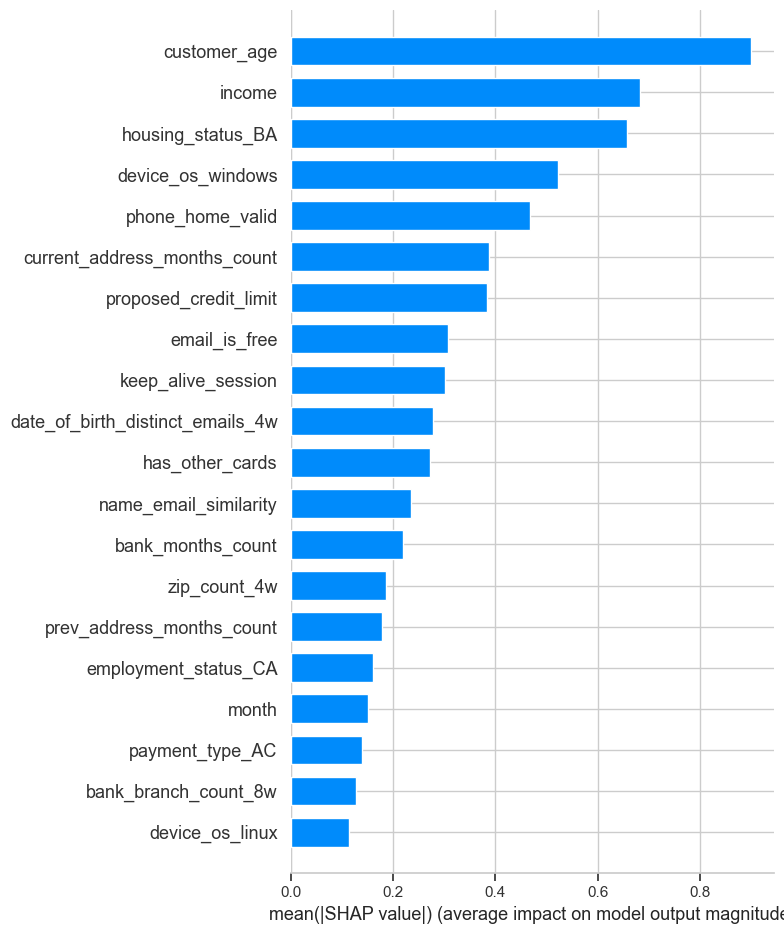

In [22]:
# Cell 9: Bar plot - Simple feature importance
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

Analyzing fraud case (true label: 1)
Model prediction: -6.565


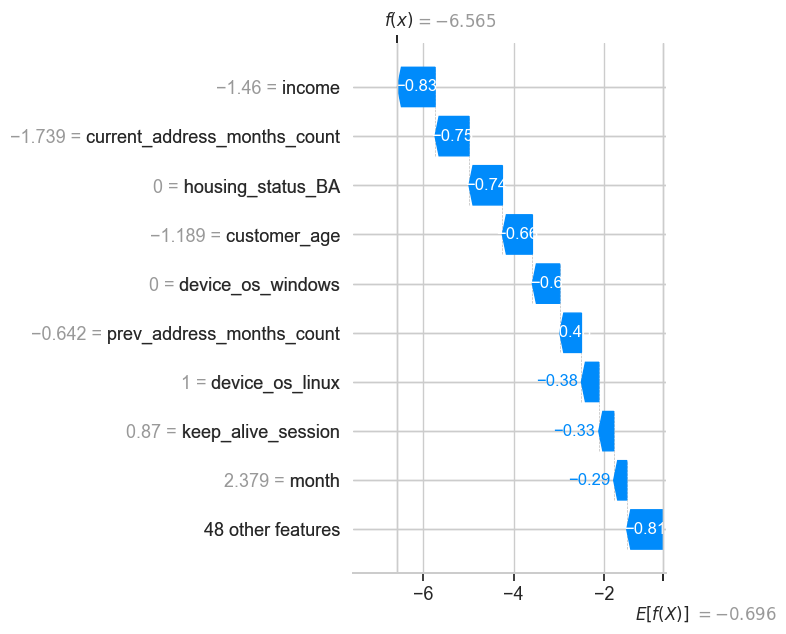

In [42]:
# Cell 10: Waterfall plot for a fraud case
fraud_indices = y_sample[y_sample == 1].index.tolist()
if fraud_indices:
    fraud_positions = [i for i, idx in enumerate(X_sample.index) if idx in fraud_indices]
    if fraud_positions:
        idx = fraud_positions[0]
        print(f"Analyzing fraud case (true label: 1)")
        print(f"Model prediction: {shap_values[idx].sum() + explainer.expected_value:.3f}")
        
        plt.figure(figsize=(14, 10))
        shap.waterfall_plot(shap.Explanation(
            values=shap_values[idx],
            base_values=explainer.expected_value,
            data=X_sample.iloc[idx].values,
            feature_names=X_sample.columns.tolist()
        ), show=False, max_display=10)
        plt.tight_layout()
        plt.show()
else:
    print("No fraud cases in the sample")

Analyzing legitimate case (true label: 0)
Model prediction: -5.908


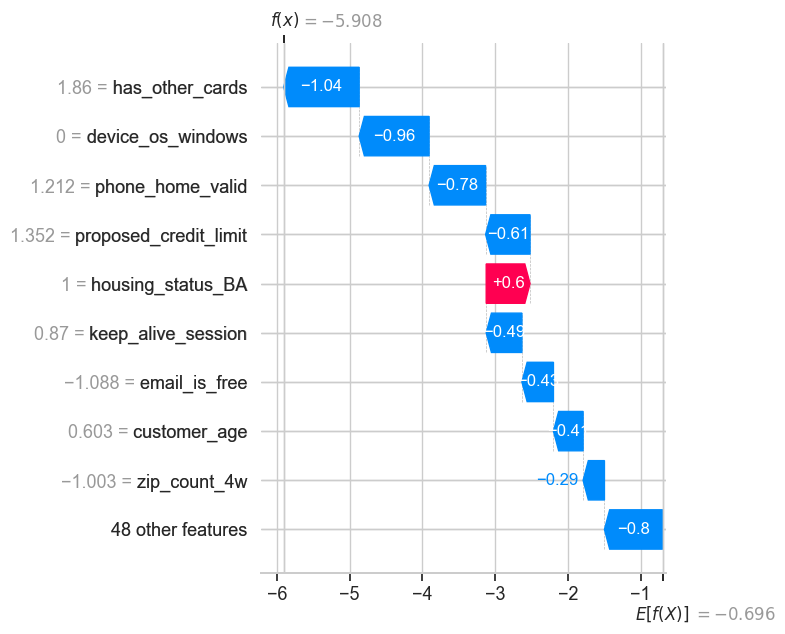

In [43]:
# Cell 11: Waterfall plot for a legitimate case
legit_indices = y_sample[y_sample == 0].index.tolist()
if legit_indices:
    legit_positions = [i for i, idx in enumerate(X_sample.index) if idx in legit_indices]
    if legit_positions:
        idx = legit_positions[0]
        print(f"Analyzing legitimate case (true label: 0)")
        print(f"Model prediction: {shap_values[idx].sum() + explainer.expected_value:.3f}")
        
        plt.figure(figsize=(14, 10))
        shap.waterfall_plot(shap.Explanation(
            values=shap_values[idx],
            base_values=explainer.expected_value,
            data=X_sample.iloc[idx].values,
            feature_names=X_sample.columns.tolist()
        ), show=False, max_display=10)
        plt.tight_layout()
        plt.show()
else:
    print("No legitimate cases in the sample")

Top feature: customer_age


<Figure size 1200x800 with 0 Axes>

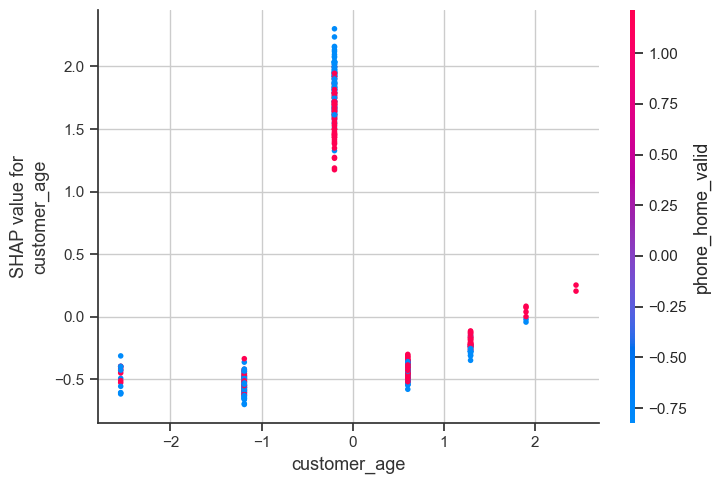

In [25]:
# Cell 12: Dependence plot for top feature
top_feature = feature_importance.iloc[0]['feature']
print(f"Top feature: {top_feature}")

plt.figure(figsize=(12, 8))
shap.dependence_plot(top_feature, shap_values, X_sample, show=False)
plt.tight_layout()
plt.show()

Second feature: income


<Figure size 1200x800 with 0 Axes>

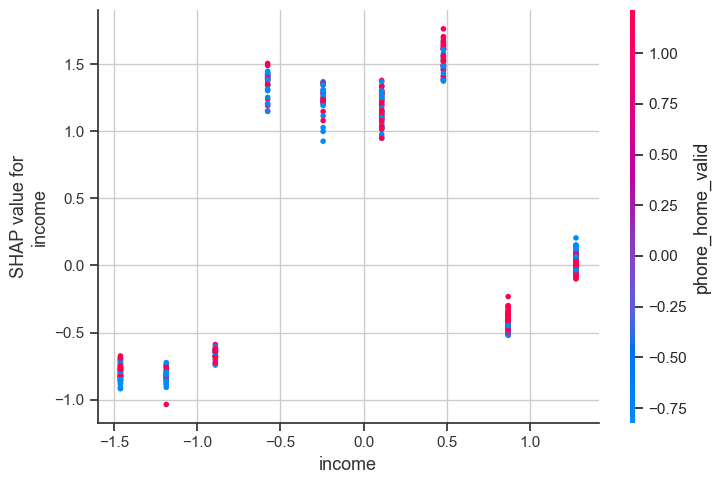

In [26]:
# Cell 13: Dependence plot for second top feature (if exists)
if len(feature_importance) > 1:
    second_feature = feature_importance.iloc[1]['feature']
    print(f"Second feature: {second_feature}")
    
    plt.figure(figsize=(12, 8))
    shap.dependence_plot(second_feature, shap_values, X_sample, show=False)
    plt.tight_layout()
    plt.show()

Retriever features analysis:
                  feature  mean_abs_shap
53   retr_total_neighbors            0.0
52  retr_local_fraud_rate            0.0
54   retr_fraud_neighbors            0.0
55   retr_similarity_mean            0.0
56    retr_similarity_max            0.0


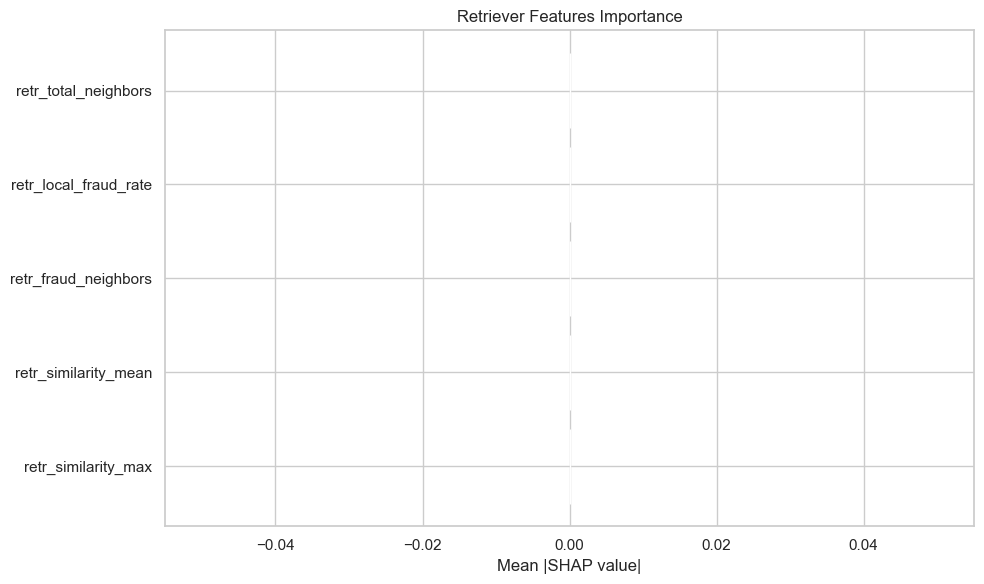

In [27]:
# Cell 14: Retriever features analysis (if they exist)
retriever_cols = [c for c in X_sample.columns if c.startswith('retr_')]
if retriever_cols:
    print("Retriever features analysis:")
    retriever_importance = feature_importance[feature_importance['feature'].isin(retriever_cols)]
    print(retriever_importance)
    
    # Plot retriever features separately
    if len(retriever_importance) > 0:
        plt.figure(figsize=(10, 6))
        plt.barh(retriever_importance['feature'], retriever_importance['mean_abs_shap'])
        plt.xlabel('Mean |SHAP value|')
        plt.title('Retriever Features Importance')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
else:
    print("No retriever features found in the model")

In [28]:
# Cell 15: Compare fraud vs legitimate average SHAP values
# Calculate average SHAP values for fraud vs legitimate cases
fraud_mask = y_sample == 1
legit_mask = y_sample == 0

avg_shap_fraud = shap_values[fraud_mask].mean(axis=0) if fraud_mask.any() else np.zeros(len(X_sample.columns))
avg_shap_legit = shap_values[legit_mask].mean(axis=0) if legit_mask.any() else np.zeros(len(X_sample.columns))

comparison_df = pd.DataFrame({
    'feature': X_sample.columns,
    'avg_shap_fraud': avg_shap_fraud,
    'avg_shap_legit': avg_shap_legit,
    'difference': avg_shap_fraud - avg_shap_legit
}).sort_values('difference', key=abs, ascending=False)

print("Features that most distinguish fraud from legitimate:")
comparison_df.head(10)

Features that most distinguish fraud from legitimate:


,feature,avg_shap_fraud,avg_shap_legit,difference
38,housing_status_BA,0.139416,-0.433632,0.573048
15,phone_home_valid,0.164147,-0.246360,0.410507
0,income,-0.048461,0.192890,-0.241350
19,proposed_credit_limit,0.191037,-0.032753,0.223791
18,has_other_cards,0.116006,-0.091746,0.207752
14,email_is_free,-0.050378,-0.169495,0.119117
22,keep_alive_session,-0.076778,-0.192602,0.115824
17,bank_months_count,0.038049,-0.073106,0.111155
4,customer_age,0.448913,0.341830,0.107083
7,zip_count_4w,-0.042688,-0.127160,0.084472


In [ ]:
# Cell 16: Summary statistics
print("\n" + "="*60)
print("SHAP ANALYSIS SUMMARY")
print("="*60)

print(f"\n📊 Data Overview:")
print(f"   - Test samples analyzed: {len(X_sample)}")
print(f"   - Fraud cases: {(y_sample == 1).sum()}")
print(f"   - Legitimate cases: {(y_sample == 0).sum()}")
print(f"   - Number of features: {len(X_sample.columns)}")

print(f"\n🏆 Top 5 Features by Importance:")
for i, row in feature_importance.head(5).iterrows():
    print(f"   {i+1}. {row['feature']}: {row['mean_abs_shap']:.4f}")

print(f"\n📁 Files saved:")
print(f"   - shap_feature_importance_enriched.csv")
print(f"   - shap_summary_enriched.png (saved from notebook)")
print(f"   - shap_bar_enriched.png (saved from notebook)")

# Optional: Save the sample data for later use
X_sample.to_csv("shap_sample_data.csv")
y_sample.to_csv("shap_sample_labels.csv")
print(f"\n✅ Sample data saved for later analysis")


SHAP ANALYSIS SUMMARY

📊 Data Overview:
   - Test samples analyzed: 500
   - Fraud cases: 10
   - Legitimate cases: 490
   - Number of features: 57

🏆 Top 5 Features by Importance:
   5. customer_age: 0.8999
   1. income: 0.6830
   39. housing_status_BA: 0.6566
   51. device_os_windows: 0.5214
   16. phone_home_valid: 0.4681

📁 Files saved:
   - shap_feature_importance_enriched.csv
   - shap_summary_enriched.png (saved from notebook)
   - shap_bar_enriched.png (saved from notebook)

✅ Sample data saved for later analysis
